<h1 style="text-align: center;">Fear & Greed Index: Exploratory Data Analysis of ETH Futures' Data</h1>

# 1. Imports

In [1]:
import sys
import os

# Manually setting the path to the FGI project directory
project_path = "C:\\Users\\Lenovo\\Desktop\\Git Uploads\\fear-and-greed"  # or "C:\\Users\\laevitas\\Desktop\\Work\\fear-and-greed"
sys.path.append(os.path.abspath(project_path))

from src.utils import (  # noqa: E402
    plot_series_analysis,
    corr_heatmap,
    pairplot,
    signal_decomp,
    plot_first_order_deriv,
)
from src.marketdata import FuturesData  # noqa: E402

# 2. Data Collection, Feature Engineering & Aggregation

- **Data Collection**: Collected all Ethereum (ETH) futures data from January 1, 2023, to October 8, 2024, with daily granularity.
  
- **Feature Extraction**: The expiration date is parsed from the contract name in the `currency` field.

- **Feature Engineering**: The **days to expiration** is calculated as the difference between the `date` column and the `expiry` column.

- **Annualizing the Basis**: The annualized basis is computed using the formula:
    $$
    \text{Annualized Basis} = \text{Basis} \times \frac{365}{\text{Days to Expiration}}
    $$

- **Aggregation**: Aggregated the `price` and `annualized_basis` by average, and summed `volume` and `open_interest` across all futures contracts to derive global figures.

- **Field Selection**: Retained only the relevant fields: `price`, `annualized_basis`, `open_interest`, and `volume`.

In [2]:
coin = "ETH"
start = "2023-01-01"
end = "2024-10-08"

futures = FuturesData(coin, start, end)

# 3. Data Cleaning

The data was cleaned using the `Z-score winsorization` method with a **threshold of 3.0** across all numerical columns. This approach capped potential outliers without removing them, ensuring that data points beyond three standard deviations from the mean were adjusted to reduce the influence of outliers while preserving the overall data structure.

In [3]:
cleaned_futures = futures.copy().z_score_cleaning()

# 4. Exploratory Data Analysis

## 4.1. Descriptive Statistics

In [4]:
cleaned_futures.historical_data.describe()

,price,annualized_basis,open_interest,volume
count,647.000000,647.000000,6.470000e+02,6.470000e+02
mean,2372.910065,7.340239,9.494229e+08,4.677395e+08
std,747.159764,5.818569,6.461379e+08,4.296013e+08
min,1195.337500,-10.455280,2.793999e+08,2.403141e+07
25%,1790.224167,2.765365,4.575993e+08,1.536400e+08
50%,2104.943750,6.485278,5.845936e+08,3.043995e+08
75%,3013.923722,10.661269,1.470044e+09,6.502264e+08
max,4265.680000,25.201261,2.721417e+09,1.926767e+09


### 4.1.1. Price Volatility


The **average price** of **$2,372.91** reflects a significant level of trading activity and market presence within the ETH futures market. Meanwhile, the **high standard deviation** of **$747.16** highlights Ethereum's price volatility, which is essential for futures traders looking to profit from price swings. This degree of variability underscores the opportunities and risks in capturing short-term price movements.


### 4.1.2. Annualized Basis

With an **average annualized basis** of **7.34%**, ETH futures generally trade at a premium over the spot market, suggesting a predominantly bullish sentiment. However, the **moderatly wide range** from a **minimum of -10.45%** to a **maximum of 25.20%** reveals that market conditions can shift considerably, with the potential for futures to trade at a discount in more bearish scenarios. This variation in the basis can impact hedging strategies and speculative positions.

### 4.1.3. Open Interest

The **mean open interest** of **$949.42 million** indicates strong participation in the ETH futures market, with many positions being held over time. However, the **high standard deviation** of **$646.14 million** shows substantial fluctuation in market engagement, which may be linked to shifts in market sentiment or external events influencing the crypto market. These swings in open interest suggest periods of heightened or diminished trader confidence.

### 4.1.4. Volume Trends


The **average trading volume** of **$467.74 million** highlights a relatively liquid market, which is vital for efficient price discovery and execution. However, the **large variability** in volume, with a **standard deviation of $429.60 million**, indicates that trading activity can vary dramatically, likely in response to market events, volatility spikes, or broader shifts in sentiment. High volume days are crucial for momentum traders, while quieter days may provide fewer opportunities.

## 4.2. Correlation Analysis

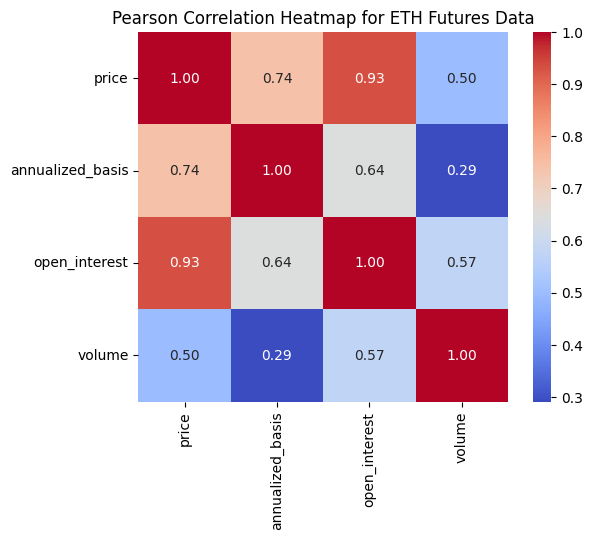

In [5]:
corr_heatmap(
    data=cleaned_futures.historical_data,
    title="Pearson Correlation Heatmap for ETH Futures Data",
    method="pearson",
)

The correlation heatmap for ETH futures data reveals the following key insights:

1. **Very Strong Positive Correlation between Price and Open Interest (0.93):**

   The **strong positive correlation** between price and open interest suggests that as ETH prices increase, open interest rises significantly as well. This indicates that more positions are being opened when prices go up, which may signal **greed** in the market as traders expect further upward movement in prices. This correlation implies a strong alignment between price trends and market engagement, making open interest a crucial factor in understanding market sentiment.

2. **Strong Positive Correlation between Price and Annualized Basis (0.74):**

   A **strong positive correlation** between price and annualized basis (unlike the case of BTC futures) indicates that when ETH prices rise, the futures market tends to trade at a higher premium. This points to a **bullish market sentiment**, as higher prices often result in traders expecting continued upward movement, reflected by an increased basis. This relationship provides insight into how market participants adjust their expectations as prices fluctuate.

3. **Strong Positive Correlation between Open Interest and Annualized Basis (0.64):**

   The **strong positive correlation** between open interest and the annualized basis suggests that as more positions are opened, the premium of futures over the spot price also tends to increase. This could indicate that traders holding open positions are more confident about price growth, a sentiment aligned with **greed**. This relationship highlights the significance of both metrics in assessing bullish or bearish market behavior, however in the context of the index it may indicate potential redundant information.

4. **Moderate Correlation between Volume and Price (0.50) and Open Interest (0.57):**

   The **moderate correlation** between volume and both price and open interest suggests that while higher prices and increased open interest are linked to rising trading volume, the relationship is not very strong like previews variables. This provides insights into **market engagement** during price rallies or dips.

5. **Relatively Weak Correlation between Annualized Basis and Volume (0.29):**

   The **weak correlation** between annualized basis and volume indicates that trading activity does not heavily influence the futures premium. This suggests that while the futures market may trade at a premium or discount, this factor is not necessarily tied to spikes or dips in trading volume, reflecting the **complex dynamics** driving market sentiment.

### Implications for the Fear & Greed Index:

- The **strong positive correlation** between price and open interest and annualized basis highlights the importance of weighting **open interest** and **annualized basis** heavily when constructing the index, as they are closely tied to price trends which is a direct proxy to market sentiment, serving as a key greed indicators.

- The **weaker correlations** with volume suggest that while volume is still a relevant factor, it may not be as critical for short-term sentiment analysis but could help capture **fluctuations in market activity**, particularly during extreme market movements.

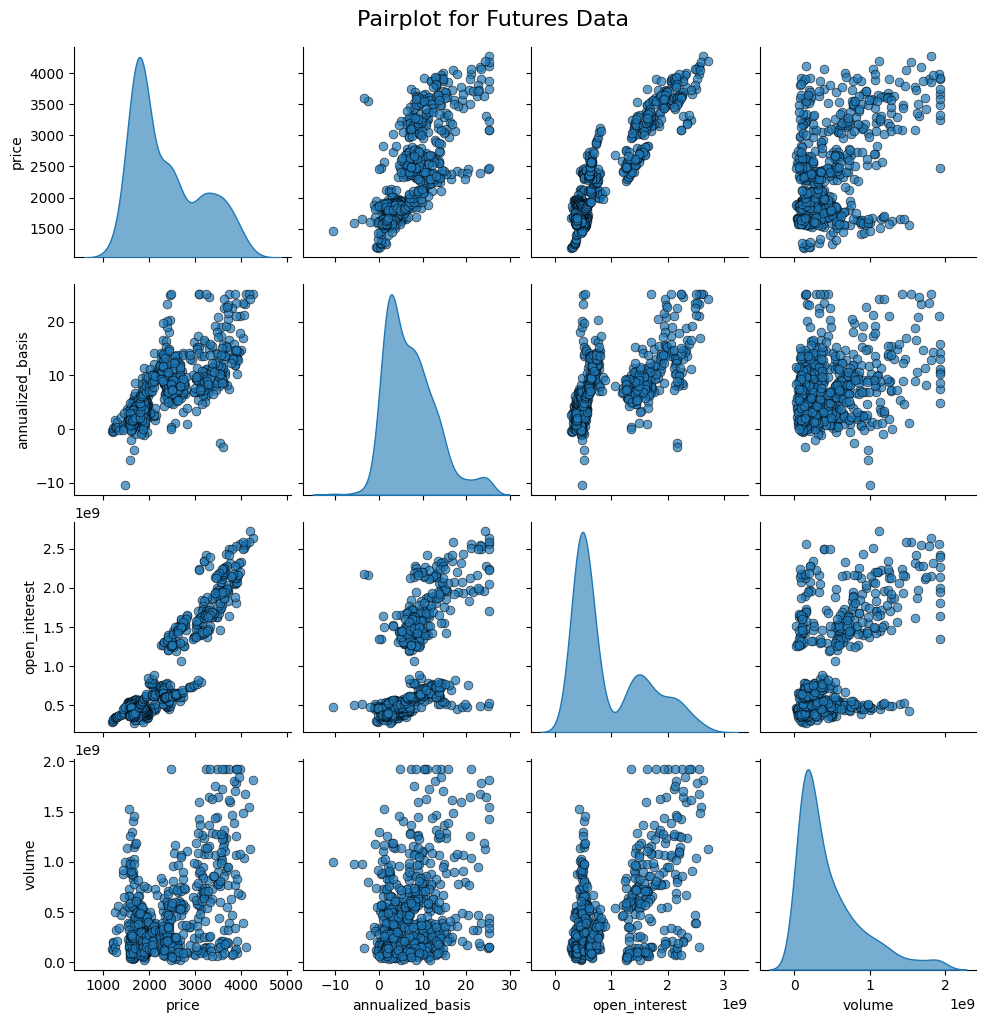

In [6]:
pairplot(cleaned_futures.historical_data, "Pairplot for Futures Data")

Focusing on the scatter plots, the pairplot reveals the relationships between variables:

1. **Price vs. Open Interest**: There is a visible positive linear correlation (confirming the choice of Pearson correlation). As the price increases, open interest also tends to increase. This suggests that when ETH futures prices are high, open interest is more concentrated.

2. **Annualized Basis vs. Open Interest**: The annualized basis and open interest show some degree of positive linear correlation. However it is a bit sparse around the regression line confirming prior results.

3. **Open Interest vs. Volume**: The relationship between open interest and volume appears to be somewhat positive. As open interest increases, the volume tends to increase slightly. However, the plot shows some scattered points, indicating that this relationship is not perfectly linear.

## 4.3. Time Series Analysis

### 4.3.1 Futures' Price

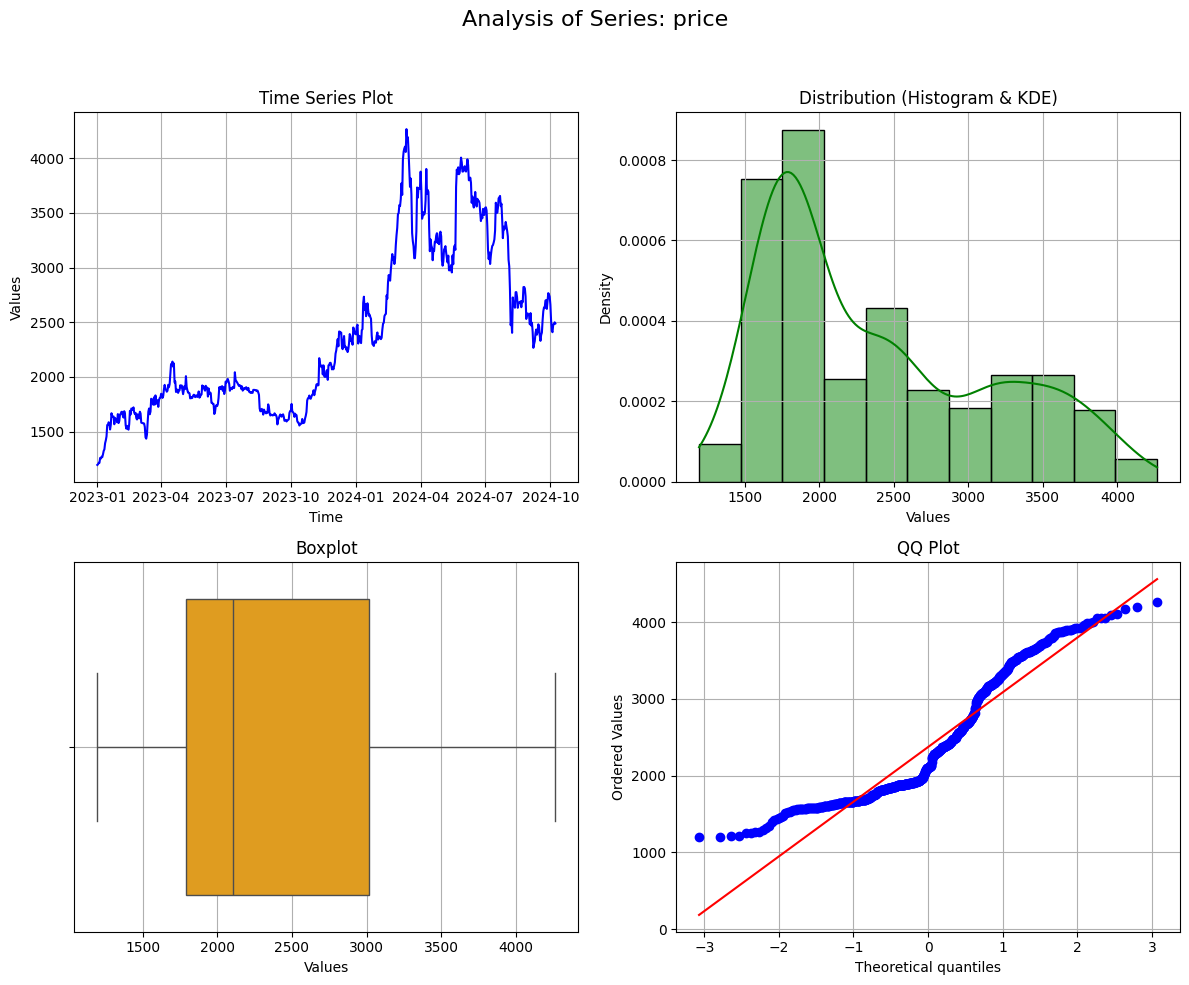

In [7]:
plot_series_analysis(cleaned_futures.historical_data["price"])

Looking at the four plots for the **price** column in the ETH futures data:

1. **Time Series Plot:** The price shows a clear upward trend from early 2023 to mid-2024, followed by periods of higher volatility. After a sharp rise in early 2024, the prices fluctuate with a downward trend but remain at higher levels. Also, a noticeable price volatility occurs after the increase in early 2024.

2. **Distribution:** The distribution of prices appears to be bimodal with two major peaks around $1,750 and $3,400, suggesting two distinct price levels during the period. This could imply market transitions or different regimes; for example switching from bullish to bearish sentiment.

3. **Boxplot:** The interquartile range is quite wide, indicating a large spread in prices. The boxplot also suggests mild right skewness, as the median is closer to the lower quartile and the upper whisker is slightly longer.

4. **QQ Plot:** The QQ plot deviates from the 45-degree line, especially at the tails. This deviation is most significant for lower prices, indicating that there are heavier tails in the distribution.

### 4.3.2. Annualized Basis

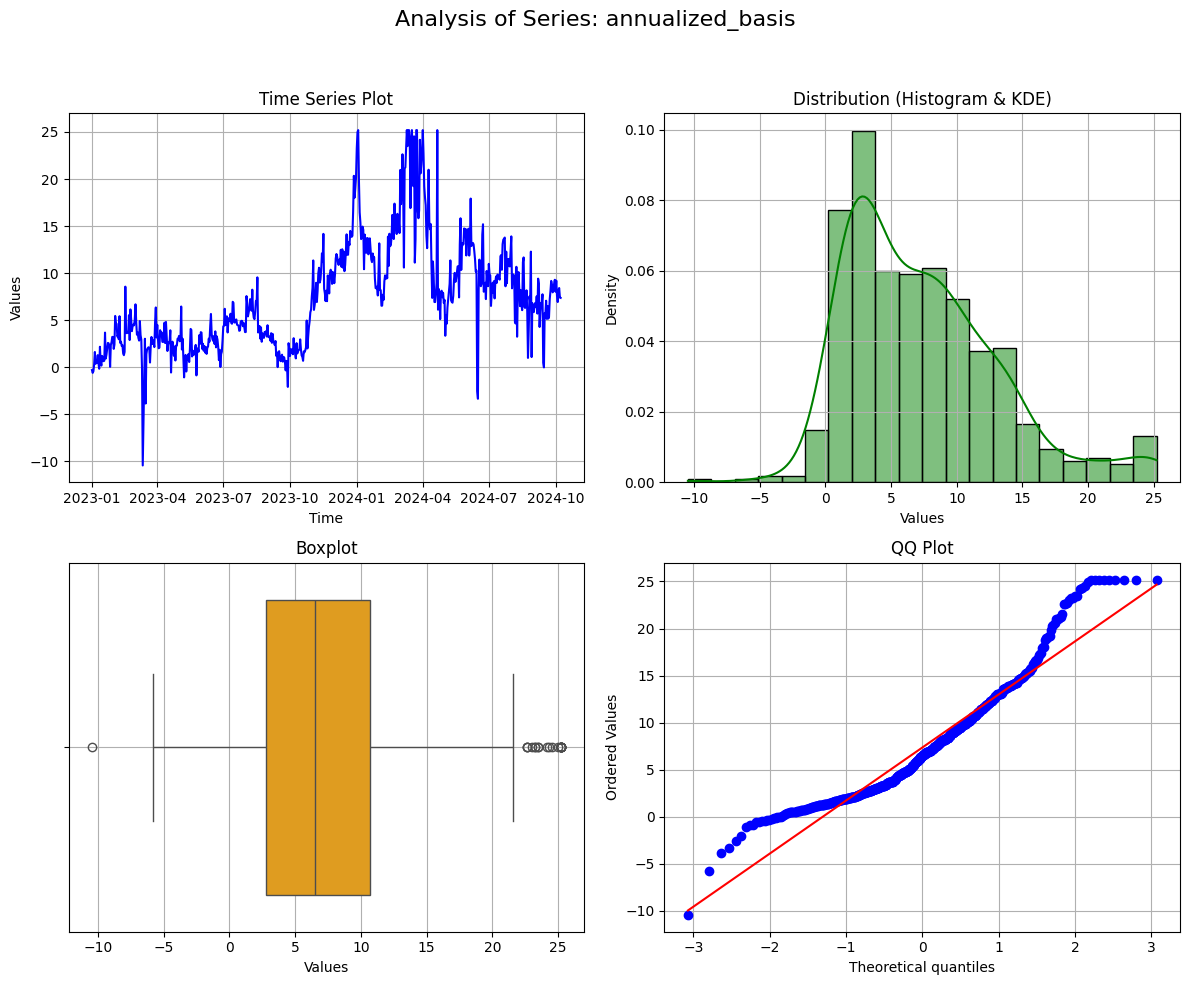

In [8]:
plot_series_analysis(cleaned_futures.historical_data["annualized_basis"])

The image presents four key plots representing the annualized basis of Bitcoin futures:

1. **Time Series Plot**: This plot shows the fluctuations in the annualized basis over time. There are clear peaks and troughs, indicating periods of sharp changes in the futures basis. The volatility seems to increase after late-2023, with some extreme values mainly on the positive side, suggesting speculative tendencies in ETH futures during that period.

2. **Distribution Plot**: The distribution is right-skewed, meaning there are some significant positive extremes compared to the negative values.

3. **Boxplot (Bottom Left)**: The interquartile range is not wide, indicating that most of the data is concentrated in a narrow range. There are quite a few extreme values below -5 and above 22, even after cleaning, further confirming the extreme movements seen in the time series.

1. **QQ Plot (Bottom Right)**: The deviations from the red line, especially at the tails, indicate that the data has fat tails.

This suggests that the ETH futures market may be experiencing speculative behavior switching back and fourth (bearish and bullish market), leading to these extreme fluctuations.

### 4.3.3. Open Interest

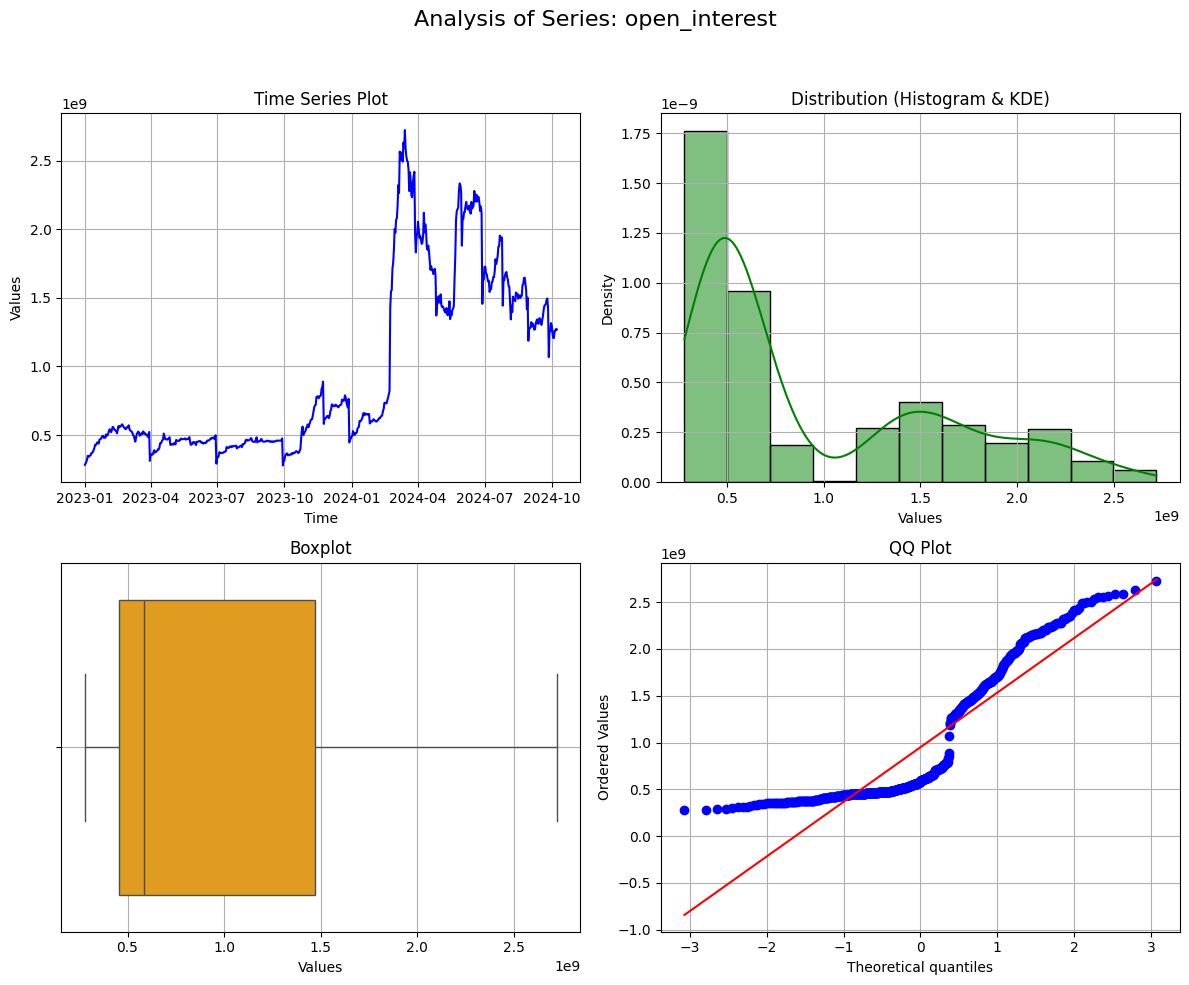

In [9]:
plot_series_analysis(cleaned_futures.historical_data["open_interest"])

Looking at the time series of the open interest:

1. **Time Series Plot**: The time series shows low and stable values from early 2023 to around the beginning of 2024, followed by a sudden spike in open interest. After the spike, open interest dips again spikes around a higher level, but overall showing a light downward trend. This suggests that the initial surge led to a lasting increase in market participation which will be curbed by the down price trend.

2. **Distribution**: The distribution is heavily right-skewed, with a majority of values clustered at lower levels before the 2024 spike. Most of the open interest is concentrated at low values, indicating that the market was relatively quiet for most of 2023. However, there is a long tail toward higher values, reflecting the significant increase in open interest post-2024, as seen in the time series. This tail suggests the presence of large market activity events that caused the spike.

3. **Boxplot**: The data is highly concentrated around the lower quartiles, reflecting the period of low activity prior to the spike. The large left whisker indicates substantial variance in the later period, likely after the market shift.

4. **QQ Plot**: The QQ plot indicates non-normality, especially in the left tail. The data significantly deviates from the red line, suggesting that the open interest behaves far differenty than a gaussian.

### 4.3.4. Volume

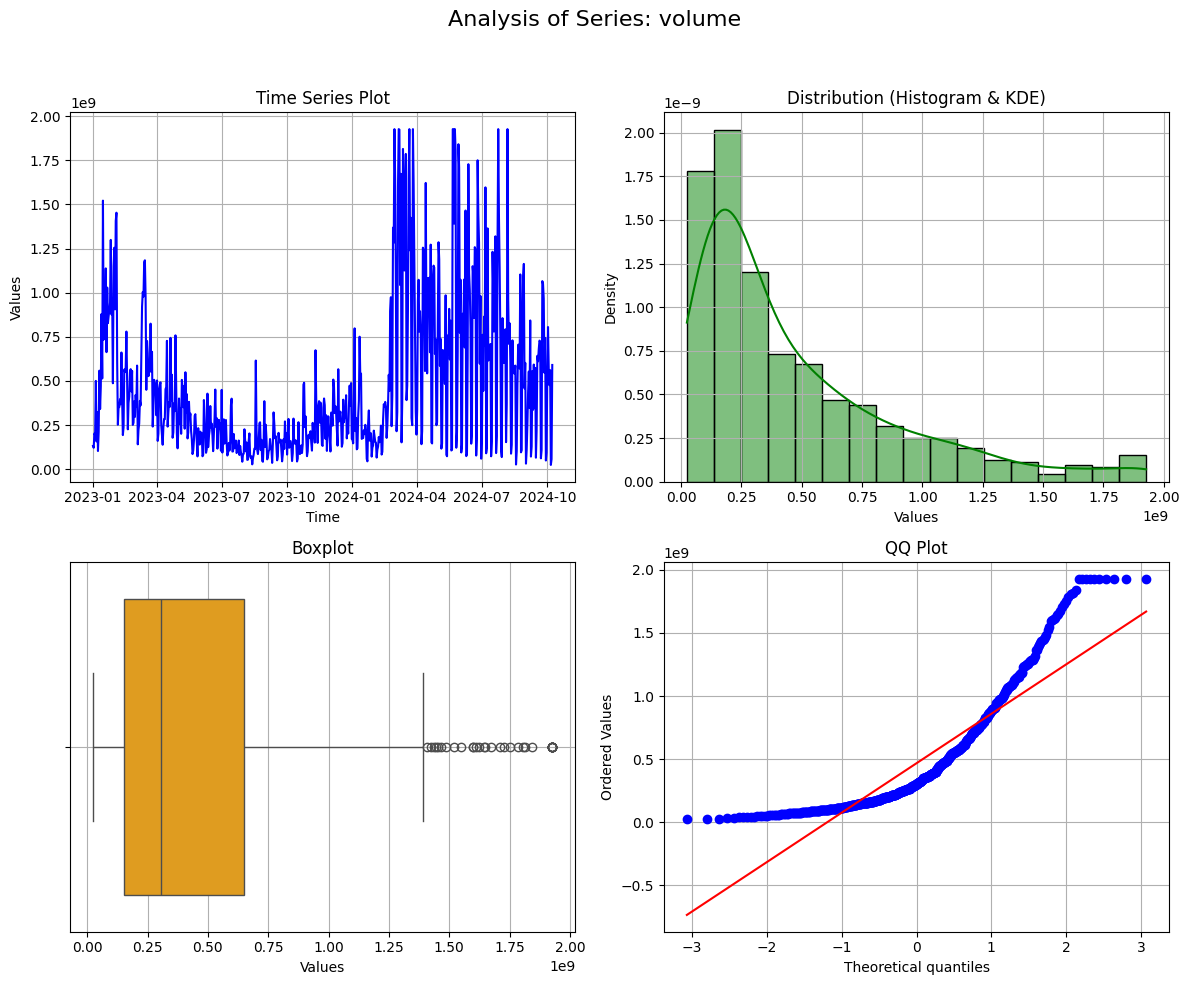

In [10]:
plot_series_analysis(cleaned_futures.historical_data["volume"])

After analyzing the volume, it is noticeable that:
1. **Time Series Plot**: The plot shows a general upward trend in volume, following the price rise and the open interest surge observed in early 2024, indicating increasing interest and trading activity over the period.
2. **Distribution**: The distribution is heavily skewed to the right, indicating that a majority of the data points are clustered towards lower values, with a few outliers pulling the tail to the right.
3. **Boxplot**: The IQR is not wide and concentrated around lower volume values. The plot also identifies several outliers on the right side, corresponding to the extreme buying sprints (greed).
4. **QQ Plot**: The points deviate from the line, indicating that the data is not normally distributed.

## 4.4. Signal Decomposition of Series usign Moving Averages

### 4.4.1. Futures' Price

In [11]:
signal_decomp(cleaned_futures.historical_data["price"])

The analysis of the decomposition of the BTC futures price time series reveals the following insights:
   
1. **Trend**: The trend component reveals a clear upward movement in ETH futures prices, especially around late 2023 and early 2024, where the most significant rise occurs. Post-April 2024, the trend seems to stabilize with a light trend downwards.
   
2. **Seasonality**: It remains relatively flat, indicating that while there may be some seasonality in the data, it is not a dominant factor in price movements. The variations in the seasonal component are minor compared to the trend.
   
3. **Residuals**: The residuals remain close to zero throughout the period, suggesting that most of the variation in price is explained by the trend.

### 4.4.2. Annualized Basis

In [12]:
annualized_basis = signal_decomp(
    cleaned_futures.historical_data["annualized_basis"], return_results=True
)

After decompostion the signal of the annualized basis, several details are revealed:
1. **Trend**: The moments of rising trend may suggest a gradual shift toward greed, while the declining trend instances could indicate increasing selling pressure or fear.

2. **Seasonality**: The variations in the seasonal component are minor compared to the trend.

3. **Residuals**: The residual component captures unexpected or exogenous shocks that drive sudden fear or greed in the market. Spikes in residuals represent periods of high uncertainty, where fear often dominates, as market reactions become harder to predict.

In [14]:
cleaned_futures.historical_data["price"].corr(annualized_basis.trend)

np.float64(0.7826368596263901)

### 4.4.3. Open Interest

In [15]:
open_interest = signal_decomp(
    cleaned_futures.historical_data["open_interest"], return_results=True
)

After decompostion the signal of the open interest, several details are revealed:
1. **Trend**: The open interest is heavily explained by trend. This component seems to capture very well the variatons of the size of the market activity which may indicate overall market sentiment.

2. **Seasonality**: The variations in the seasonal component are minor compared to the trend.

3. **Residuals**: The variations in the residual component are minor compared to the trend and remains very flat.

### 4.4.4. Volume

In [16]:
volume = signal_decomp(cleaned_futures.historical_data["volume"], return_results=True)

1. **Trend**: The trend component indicates a growing interest in ETH futures trading after a stable low volume market for most of 2023 and early 2024.

2. **Seasonality**: The variations in the seasonal component are minor compared to the trend.

3. **Residuals**: The residual component is randomly distributed around 0 and is highly volatile especially in the second phase (post-2024 surge) indicating the randomness of the volume variations, again, representing the periods of high uncertainty.

In [17]:
volume.trend.corr(open_interest.trend)

np.float64(0.7911555020580053)

In [13]:
plot_first_order_deriv(annualized_basis.trend)